# Is the task vector ≈ the aggregated input→output difference?

Hypothesis: the model forms the task representation by aggregating, across demos, the
relation between each input and its output. Simplest form of that relation: the embedding
difference `emb(output) − emb(input)`. So the task vector should align with
`mean_demos [ emb(out) − emb(in) ]`.

Test (cosine, no probe):
- build `delta_task = mean over demos of (emb(out) - emb(in))` for each task.
- compare (cosine) to the actual extracted task vector at the final position.
- controls: (a) cosine to the WRONG task's delta (should be lower);
            (b) shuffled input-output pairing delta (should be lower);
            (c) just mean emb(out), and just -mean emb(in), to see which half drives it.

`experiments/interplay/`.

In [1]:
import os, sys, pickle
sys.path.insert(0, os.path.abspath('../..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch
from tqdm.auto import tqdm

import experiments.pairing._common as C
from data.loaders import load_dataset
sns.set_context('notebook')

## Config

In [2]:
DATASET   = 'nonce+arithmetic'
N_PROMPTS = 30
TV_LAYER  = 13            # layer to extract the task vector (final/query-arrow position)
CUDA      = '0'
ds_tag = DATASET.replace('+','_')

model = C.load_model(cuda_visible=CUDA)
n_layers = model.cfg.n_layers
splits = load_dataset(DATASET)
tasks = sorted(splits.keys())
W_E = model.W_E.detach().float()    # (vocab, d_model) token embeddings
d_model = model.cfg.d_model
print(f'{DATASET}: {len(tasks)} tasks, TV layer {TV_LAYER}')

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
nonce+arithmetic: 20 tasks, TV layer 13


## Build delta_task = mean over demos of (emb(out) - emb(in))
Use the first token id of ' '+word for input and output (consistent with the rest of the
project). One delta per prompt, averaged over its demos; then mean over prompts -> task delta.

In [3]:
def tok0(word):
    return model.to_tokens(' '+str(word), prepend_bos=False)[0,0].item()

def prompt_delta(demos, shuffle=False, rng=None):
    ins=[a for a,_ in demos]; outs=[b for _,b in demos]
    if shuffle:
        outs=list(outs); rng.shuffle(outs)
    d=[]
    for a,b in zip(ins,outs):
        d.append(W_E[tok0(b)].cpu().numpy() - W_E[tok0(a)].cpu().numpy())
    return np.mean(d,axis=0)

def mean_out(demos):
    return np.mean([W_E[tok0(b)].cpu().numpy() for _,b in demos],axis=0)
def mean_in(demos):
    return np.mean([W_E[tok0(a)].cpu().numpy() for a,_ in demos],axis=0)

import random
rng=random.Random(0)
delta_task, mout_task, min_task, delta_shuf = {}, {}, {}, {}
for t in tasks:
    ps = splits[t]['icl_prompts'][:N_PROMPTS]
    delta_task[t]=np.mean([prompt_delta(p['demo_pairs']) for p in ps],axis=0)
    delta_shuf[t]=np.mean([prompt_delta(p['demo_pairs'],shuffle=True,rng=rng) for p in ps],axis=0)
    mout_task[t]=np.mean([mean_out(p['demo_pairs']) for p in ps],axis=0)
    min_task[t]=np.mean([mean_in(p['demo_pairs']) for p in ps],axis=0)
print('built deltas for', len(tasks), 'tasks')

built deltas for 20 tasks


## Extract the actual task vector (final/query-arrow position, layer TV_LAYER)
Averaged over prompts per task — the clean per-task TV.

In [4]:
@torch.no_grad()
def tv_for_prompt(prompt, layer):
    arrow=C.query_arrow_position(model, prompt)
    toks=model.to_tokens(prompt, prepend_bos=True)
    _,cache=model.run_with_cache(toks, names_filter=lambda n:n==f'blocks.{layer}.hook_resid_post')
    v=cache[f'blocks.{layer}.hook_resid_post'][0,arrow].float().cpu().numpy()
    del cache; torch.cuda.empty_cache(); return v

tv_task={}
for t in tqdm(tasks):
    tv_task[t]=np.mean([tv_for_prompt(p['prompt'],TV_LAYER) for p in splits[t]['icl_prompts'][:N_PROMPTS]],axis=0)
print('extracted TVs')

  0%|          | 0/20 [00:00<?, ?it/s]

extracted TVs


## Cosine comparisons
For each task, cosine(TV, delta_task) vs the controls.

In [5]:
def cos(a,b): 
    return float(a@b/(np.linalg.norm(a)*np.linalg.norm(b)+1e-12))

rows=[]
for t in tasks:
    tv=tv_task[t]
    # wrong-task control: mean cosine to OTHER tasks' deltas
    wrong=np.mean([cos(tv, delta_task[o]) for o in tasks if o!=t])
    rows.append({'task':t,
                 'cos_delta': cos(tv, delta_task[t]),
                 'cos_delta_shuffled': cos(tv, delta_shuf[t]),
                 'cos_wrong_task_delta': wrong,
                 'cos_mean_out': cos(tv, mout_task[t]),
                 'cos_neg_mean_in': cos(tv, -min_task[t])})
R=pd.DataFrame(rows)
print(R.round(3).to_string(index=False))
print('\n=== means over tasks ===')
print(R.drop(columns='task').mean().round(3).to_string())

         task  cos_delta  cos_delta_shuffled  cos_wrong_task_delta  cos_mean_out  cos_neg_mean_in
       add_13      0.000               0.000                -0.001        -0.015            0.015
        add_3      0.000               0.000                -0.000        -0.006            0.006
        add_7      0.000               0.000                 0.000        -0.013            0.013
  append_last      0.008               0.008                -0.006        -0.033            0.034
double_vowels     -0.003              -0.003                -0.004        -0.022            0.023
   drop_first     -0.009              -0.009                -0.002        -0.028            0.021
    drop_last     -0.009              -0.009                -0.004        -0.031            0.033
  mul_2_add_1      0.000               0.000                -0.001        -0.023            0.023
  mul_2_sub_1      0.000               0.000                -0.002        -0.024            0.024
  mul_3_add_2      0

## Plot

/tmp/ipykernel_5269/2440409632.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Δ = out−in','Δ shuffled','Δ wrong task','mean out','−mean in'], rotation=20)


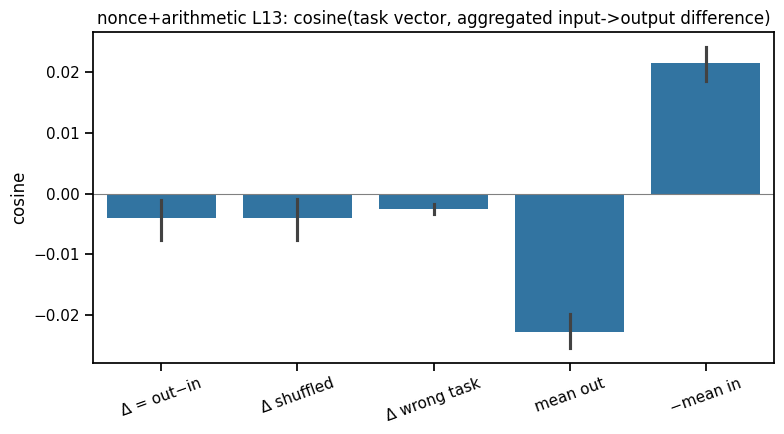

In [6]:
m = R.drop(columns='task').mean().reindex(
    ['cos_delta','cos_delta_shuffled','cos_wrong_task_delta','cos_mean_out','cos_neg_mean_in'])
fig,ax=plt.subplots(figsize=(8,4.5))
melt=R.melt(id_vars='task', value_vars=m.index, var_name='comparison', value_name='cosine')
sns.barplot(melt, x='comparison', y='cosine', order=m.index, errorbar=('ci',95), ax=ax)
ax.axhline(0, color='gray', lw=.8)
ax.set(title=f'{DATASET} L{TV_LAYER}: cosine(task vector, aggregated input->output difference)',
       ylabel='cosine', xlabel='')
ax.set_xticklabels(['Δ = out−in','Δ shuffled','Δ wrong task','mean out','−mean in'], rotation=20)
plt.tight_layout(); plt.show()

## Read it
- **cos_delta high, and > shuffled & > wrong-task** -> the TV aligns with the aggregated
  out−in difference specifically: the task vector IS (in part) the aggregated transform.
  Hypothesis supported.
- **cos_delta ≈ cos_mean_out (and −mean_in ≈ 0)** -> it's really just the average OUTPUT
  embedding driving it (consistent with your earlier 'TV formed from outputs' result),
  not the difference per se. Important alternative to rule out.
- **cos_delta ≈ shuffled** -> pairing doesn't matter for the TV's alignment (it's output-driven).
- Try TV_LAYER sweep; the alignment should peak near the TV-formation layers.

In [7]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from utils.heads import select_scope

pairing    = select_scope(ms, SCOPE)['pairing']
rand_heads = select_scope(ms, SCOPE)['pairing_rand']

def task_discrim(headname):
    sel = (meta.headname==headname).values
    X = V[sel]; tk = meta.task[sel].values
    Xn = X/(np.linalg.norm(X,axis=1,keepdims=True)+1e-9)
    tasks_u = np.unique(tk)
    cents = {t: Xn[tk==t].mean(0) for t in tasks_u}
    cents = {t: c/(np.linalg.norm(c)+1e-9) for t,c in cents.items()}
    within = np.mean([Xn[i] @ cents[tk[i]] for i in range(len(Xn))])
    C = np.stack([cents[t] for t in tasks_u]); G = C @ C.T; n=len(tasks_u)
    between = (G.sum()-np.trace(G))/(n*(n-1))
    return within, between, within-between

rows=[]
for hn in sorted(set(f'{l}.{h}' for l,h in pairing) | set(f'{l}.{h}' for l,h in rand_heads),
                 key=lambda s:(int(s.split('.')[0]),int(s.split('.')[1]))):
    if hn not in set(meta.headname): continue
    w,b,s = task_discrim(hn)
    grp = 'pairing' if tuple(map(int,hn.split('.'))) in set(pairing) else 'random'
    rows.append({'head':hn,'group':grp,'within':w,'between':b,'separation':s})
D=pd.DataFrame(rows)
print(D.groupby('group')[['within','between','separation']].mean().round(3).to_string())
fig,ax=plt.subplots(figsize=(7,4.5))
sns.boxplot(D, x='group', y='separation', ax=ax)
sns.stripplot(D, x='group', y='separation', color='k', size=3, alpha=.5, ax=ax)
ax.axhline(0,color='gray',lw=.8)
ax.set(title='task separation of OV writes (within−between cosine): pairing vs random',
       ylabel='within − between task cosine')
plt.tight_layout(); plt.show()

NameError: name 'ms' is not defined